# 03 Estadística e Hipótesis
## Tennis Performance Intelligence

**Objetivo:** aplicar estadística descriptiva e inferencial sobre el dataset de
partidos para caracterizar distribuciones, evaluar relaciones (correlación y
regresión simple), y validar formalmente hipótesis de negocio sobre los factores
asociados al resultado de un partido.

**Input:** `data/processed/matches_clean.parquet`
**Autor:** Juan Felipe Lozano

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_parquet("/content/matches_clean.parquet")
df_eda = df[df["status"] == "FINISHED"].copy()

print(f"Partidos finalizados: {len(df_eda):,}")
df_eda.head()

Partidos finalizados: 74,578


,match_id,season_year,tour_type,tour_type_human,date_timestamp,date_human,tournament,round,surface,surface_id,status,status_extra,home_name,away_name,home_id,away_id,home_rank,away_rank,home_points,away_points,winner_code,home_set_score,away_set_score,home_set_1_score,away_set_1_score,home_set_2_score,away_set_2_score,home_set_3_score,away_set_3_score,home_set_4_score,away_set_4_score,home_set_5_score,away_set_5_score,home_odds_match_winner,away_odds_match_winner,home_odds_first_set_winner,away_odds_first_set_winner,home_aces,away_aces,home_double_faults,away_double_faults,home_service_points_won_perc,away_service_points_won_perc,home_return_points_won_perc,away_return_points_won_perc,home_break_points_won_perc,away_break_points_won_perc,home_break_points_saved_perc,away_break_points_saved_perc,source_file,unique_match_id,match_date
0,88631370,2023,1,Atp Tour,1672276200,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Fritz T.,Lehecka J.,723636,563621,9.0,81.0,3355.0,646.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.13,5.5,1.22,4.00,5.0,4.0,3.0,1.0,68.0,67.0,33.0,32.0,67.0,0.0,100.0,33.0,2023-atp-season.csv,88631370_2023_1,2022-12-29 01:10:00
1,12903993,2023,1,Atp Tour,1672289400,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Musetti L.,Meligeni Alves F.,340250,182021,23.0,166.0,1865.0,343.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.08,7.0,1.17,4.50,9.0,1.0,1.0,2.0,67.0,54.0,46.0,33.0,100.0,67.0,33.0,0.0,2023-atp-season.csv,12903993_2023_1,2022-12-29 04:50:00
2,32392525,2023,1,Atp Tour,1672296900,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Tsitsipas S.,Dimitrov G.,249143,945948,4.0,28.0,5550.0,1460.0,1.0,2.0,1.0,4.0,6.0,6.0,2.0,7.0,6.0,NaN,NaN,NaN,NaN,1.29,3.5,1.40,2.75,12.0,11.0,1.0,2.0,72.0,72.0,28.0,28.0,25.0,11.0,89.0,75.0,2023-atp-season.csv,32392525_2023_1,2022-12-29 06:55:00
3,89690005,2023,1,Atp Tour,1672301400,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,De Minaur A.,Norrie C.,284548,701944,24.0,14.0,1790.0,2445.0,2.0,0.0,2.0,3.0,6.0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1.62,2.2,1.67,2.10,3.0,4.0,1.0,1.0,60.0,71.0,29.0,40.0,0.0,33.0,67.0,100.0,2023-atp-season.csv,89690005_2023_1,2022-12-29 08:10:00
4,50341526,2023,1,Atp Tour,1672313100,29 Dec 2022,United Cup ATP,Nan,Hard,1,FINISHED,FINISHED,Huesler M.,Skatov T.,488936,508090,56.0,142.0,818.0,387.0,1.0,2.0,1.0,4.0,6.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,1.22,4.0,1.30,3.40,6.0,4.0,1.0,2.0,65.0,61.0,39.0,35.0,43.0,14.0,86.0,57.0,2023-atp-season.csv,50341526_2023_1,2022-12-29 11:25:00


## 1. Estadística descriptiva

Se calculan medidas de tendencia central, dispersión y percentiles para las
variables numéricas clave, como base para entender la forma de sus distribuciones
antes de aplicar pruebas de hipótesis.

In [3]:
desc_cols = [
    "home_rank", "away_rank",
    "home_service_points_won_perc", "away_service_points_won_perc",
    "home_aces", "away_aces",
]
desc_cols = [c for c in desc_cols if c in df_eda.columns]

desc_stats = df_eda[desc_cols].describe(percentiles=[.10, .25, .5, .75, .90]).T
desc_stats["var"] = df_eda[desc_cols].var()
desc_stats.round(2)

,count,mean,std,min,10%,25%,50%,75%,90%,max,var
home_rank,41706.0,257.99,255.86,1.0,34.0,90.0,197.0,334.0,539.0,2258.0,65465.61
away_rank,41649.0,269.98,264.97,1.0,36.0,97.0,202.0,348.0,573.0,2278.0,70208.52
home_service_points_won_perc,73620.0,60.19,10.88,0.0,47.0,54.0,61.0,67.0,73.0,100.0,118.27
away_service_points_won_perc,73620.0,59.55,10.86,0.0,47.0,53.0,60.0,67.0,72.0,100.0,117.97
home_aces,73626.0,3.98,3.97,0.0,0.0,1.0,3.0,6.0,9.0,47.0,15.77
away_aces,73626.0,3.90,3.94,0.0,0.0,1.0,3.0,6.0,9.0,51.0,15.49


## 2. Distribuciones

Se visualiza la forma de las distribuciones de variables clave, importante para
decidir qué prueba estadística es apropiada más adelante (pruebas paramétricas
como t-test asumen cierta normalidad; si no se cumple, se recurre a alternativas
no paramétricas).

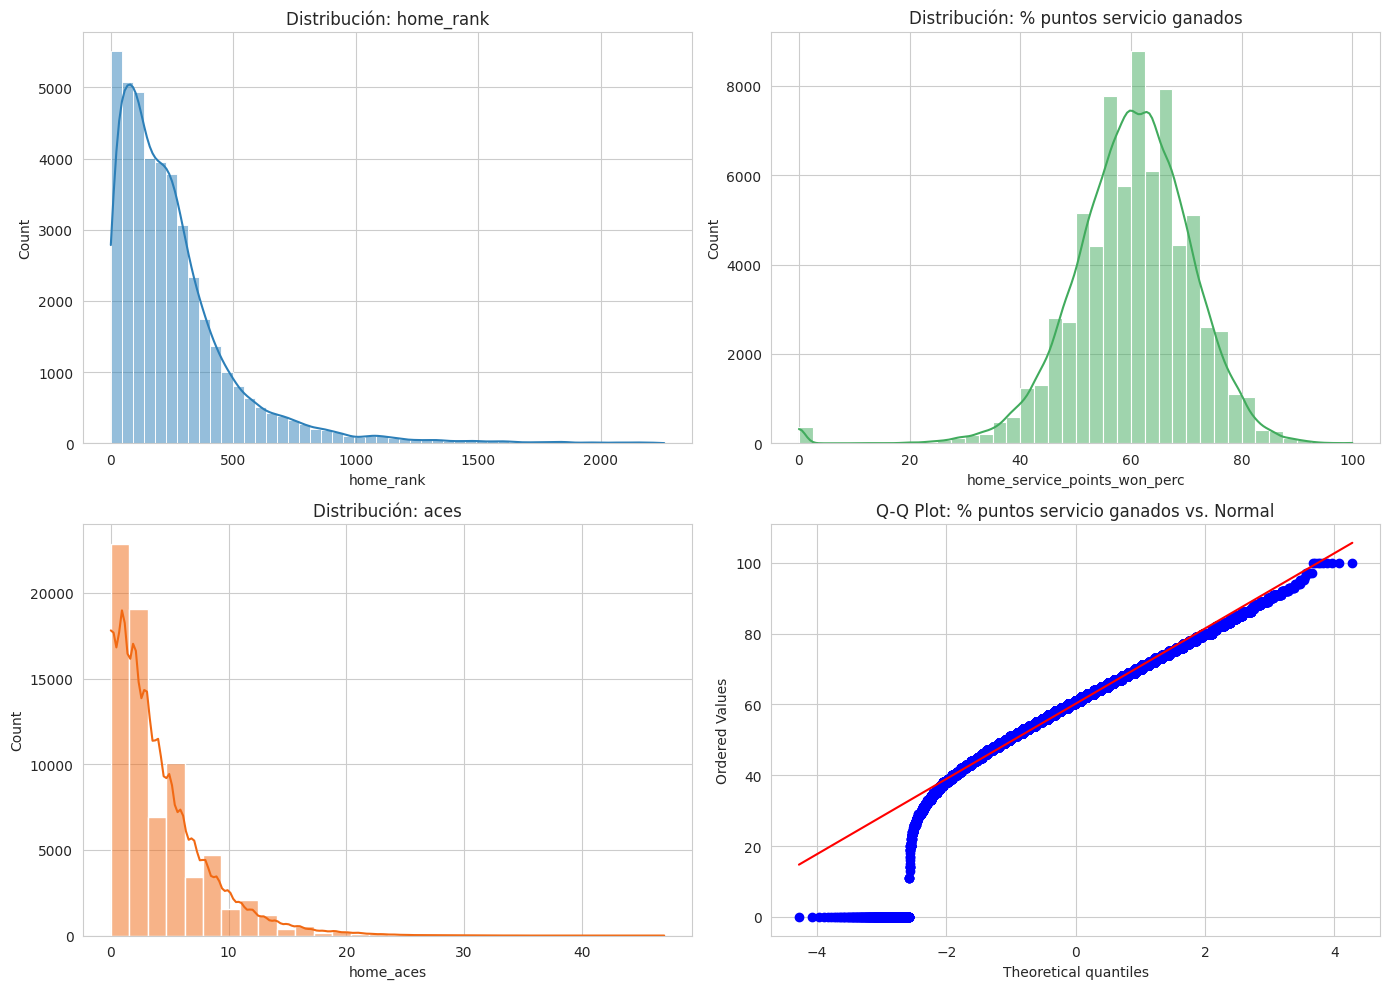

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_eda["home_rank"].dropna(), bins=50, kde=True, ax=axes[0,0], color="#2c7fb8")
axes[0,0].set_title("Distribución: home_rank")

sns.histplot(df_eda["home_service_points_won_perc"].dropna(), bins=40, kde=True, ax=axes[0,1], color="#41ab5d")
axes[0,1].set_title("Distribución: % puntos servicio ganados")

sns.histplot(df_eda["home_aces"].dropna(), bins=30, kde=True, ax=axes[1,0], color="#f16913")
axes[1,0].set_title("Distribución: aces")

stats.probplot(df_eda["home_service_points_won_perc"].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot: % puntos servicio ganados vs. Normal")

plt.tight_layout()
plt.show()

**Interpretación:** `home_rank` muestra una distribución fuertemente asimétrica
a la derecha (esperable, pocos jugadores en el top del ranking, cola larga hacia
rankings altos). `home_service_points_won_perc` se aproxima razonablemente a una
distribución normal (confirmado por el Q-Q plot), lo que respalda el uso de
pruebas paramétricas (t-test) sobre esta variable en la sección de hipótesis.

## 3. Probabilidad y muestreo

Se estima la probabilidad empírica de victoria del favorito y se evalúa la
estabilidad de esa estimación mediante muestreo repetido (bootstrap), como
introducción práctica a conceptos de probabilidad e inferencia.

In [5]:
df_rank = df_eda.dropna(subset=["home_rank", "away_rank", "winner_code"]).copy()
df_rank["favorite_won"] = np.where(
    df_rank["home_rank"] < df_rank["away_rank"],
    df_rank["winner_code"] == 1,
    df_rank["winner_code"] == 2
)

p_hat = df_rank["favorite_won"].mean()
n = len(df_rank)
print(f"Probabilidad empírica de victoria del favorito: {p_hat:.4f} ({p_hat*100:.1f}%)")
print(f"Tamaño de muestra: {n:,}")

# Bootstrap: remuestreo con reemplazo para estimar la variabilidad de p_hat
np.random.seed(42)
boot_estimates = [
    df_rank["favorite_won"].sample(n=n, replace=True).mean()
    for _ in range(1000)
]

ci_lower, ci_upper = np.percentile(boot_estimates, [2.5, 97.5])
print(f"\nIntervalo de confianza 95% (bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")

Probabilidad empírica de victoria del favorito: 0.6257 (62.6%)
Tamaño de muestra: 40,760

Intervalo de confianza 95% (bootstrap): [0.6214, 0.6307]


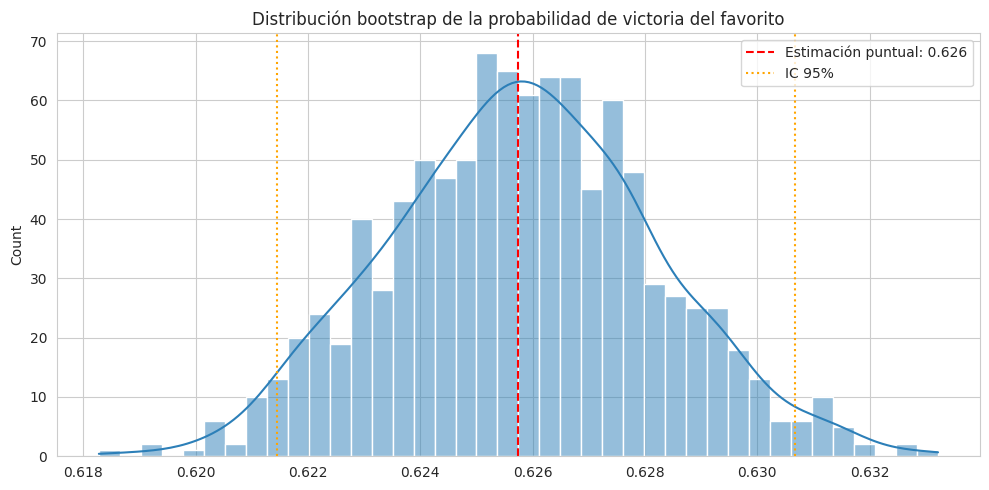

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(boot_estimates, bins=40, kde=True, ax=ax, color="#2c7fb8")
ax.axvline(p_hat, color="red", linestyle="--", label=f"Estimación puntual: {p_hat:.3f}")
ax.axvline(ci_lower, color="orange", linestyle=":", label="IC 95%")
ax.axvline(ci_upper, color="orange", linestyle=":")
ax.set_title("Distribución bootstrap de la probabilidad de victoria del favorito")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Correlación (formalización)

En el Notebook 2 se identificaron correlaciones visualmente. Aquí se formaliza
el coeficiente de correlación de Pearson entre `rank_diff` y el resultado, con
su significancia estadística.

In [7]:
df_rank["rank_diff_signed"] = df_rank["home_rank"] - df_rank["away_rank"]
df_rank["home_won"] = (df_rank["winner_code"] == 1).astype(int)

r, p_value_corr = stats.pearsonr(df_rank["rank_diff_signed"], df_rank["home_won"])

print(f"Correlación de Pearson (rank_diff_signed vs. home_won): r = {r:.4f}")
print(f"p-value: {p_value_corr:.2e}")
print(f"\nInterpretación: correlación {'débil' if abs(r)<0.3 else 'moderada' if abs(r)<0.6 else 'fuerte'}, "
      f"{'estadísticamente significativa' if p_value_corr < 0.05 else 'no significativa'} al 95% de confianza.")

Correlación de Pearson (rank_diff_signed vs. home_won): r = -0.2411
p-value: 0.00e+00

Interpretación: correlación débil, estadísticamente significativa al 95% de confianza.


## 5. Regresión simple

Se ajusta una regresión lineal simple entre diferencia de ranking y probabilidad
de victoria, como exploración introductoria de relación funcional, distinto del
modelado predictivo formal del Notebook 4 (que usará clasificación, no regresión
lineal, y un conjunto más amplio de features).

Pendiente (slope): 0.000233
Intercepto: 0.5779
R²: 0.9341
p-value: 0.0001


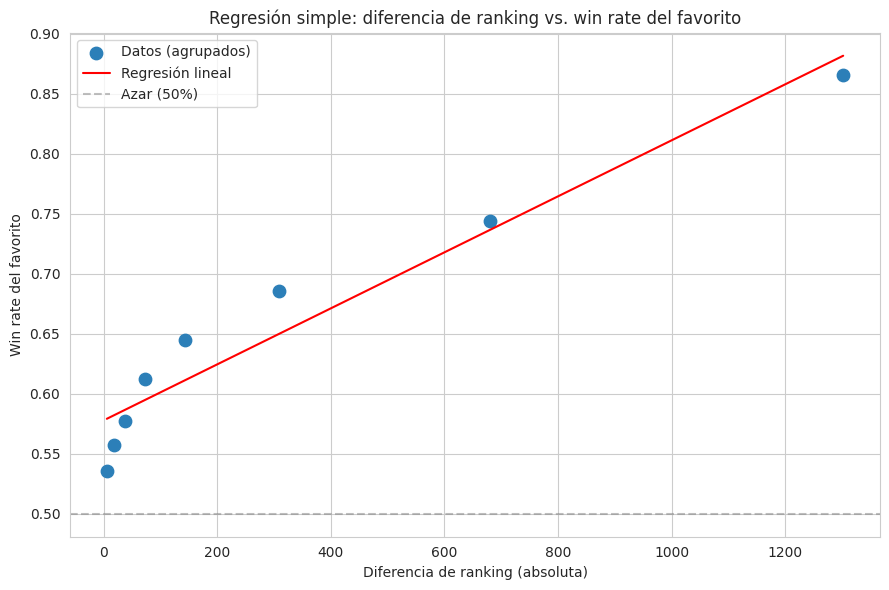

In [8]:
from scipy.stats import linregress

# Se agrupa por bucket de rank_diff absoluto para suavizar el ruido y ver la tendencia
df_rank["abs_rank_diff"] = abs(df_rank["rank_diff_signed"])
bins = [0, 10, 25, 50, 100, 200, 500, 1000, np.inf]
df_rank["diff_bin"] = pd.cut(df_rank["abs_rank_diff"], bins=bins)

binned = df_rank.groupby("diff_bin").agg(
    mid_point=("abs_rank_diff", "mean"),
    win_rate=("favorite_won", "mean")
).dropna()

slope, intercept, r_value, p_value_reg, std_err = linregress(binned["mid_point"], binned["win_rate"])

print(f"Pendiente (slope): {slope:.6f}")
print(f"Intercepto: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value_reg:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(binned["mid_point"], binned["win_rate"], s=80, color="#2c7fb8", label="Datos (agrupados)")
x_line = np.linspace(binned["mid_point"].min(), binned["mid_point"].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="red", label="Regresión lineal")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Azar (50%)")
ax.set_xlabel("Diferencia de ranking (absoluta)")
ax.set_ylabel("Win rate del favorito")
ax.set_title("Regresión simple: diferencia de ranking vs. win rate del favorito")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Prueba de hipótesis 1 — ¿Gana el favorito más que por azar?

**H0 (hipótesis nula):** la probabilidad de que gane el jugador con mejor ranking
es igual a 0.5 (equivalente al azar, sin ventaja real).

**H1 (hipótesis alternativa):** la probabilidad de que gane el jugador con mejor
ranking es distinta de 0.5.

**Nivel de significancia:** α = 0.05

**Prueba:** test de proporción de una muestra (z-test para proporciones), dado
que se compara una proporción observada contra un valor de referencia fijo (0.5)
con una muestra grande (n=40,760).

In [9]:
from statsmodels.stats.proportion import proportions_ztest

count_favorite_wins = df_rank["favorite_won"].sum()
n_total = len(df_rank)

z_stat, p_value_h1 = proportions_ztest(count=count_favorite_wins, nobs=n_total, value=0.5)

print(f"Proporción observada: {count_favorite_wins/n_total:.4f}")
print(f"Estadístico z: {z_stat:.4f}")
print(f"p-value: {p_value_h1:.2e}")

alpha = 0.05
if p_value_h1 < alpha:
    print(f"\nConclusión: se RECHAZA H0 (p-value < {alpha}). Existe evidencia estadísticamente")
    print("significativa de que el favorito gana más seguido que lo esperado por azar.")
else:
    print(f"\nConclusión: NO se rechaza H0 (p-value >= {alpha}). No hay evidencia suficiente")
    print("para afirmar que el favorito gana distinto al azar.")

Proporción observada: 0.6257
Estadístico z: 52.4556
p-value: 0.00e+00

Conclusión: se RECHAZA H0 (p-value < 0.05). Existe evidencia estadísticamente
significativa de que el favorito gana más seguido que lo esperado por azar.


**Limitaciones de esta prueba:**
- Se asume independencia entre observaciones (partidos), lo cual es razonable
  pero no perfecto, un mismo jugador aparece en múltiples partidos, generando
  cierta correlación intra-jugador no modelada aquí.
- El resultado es válido solo para partidos con ranking disponible en ambos
  jugadores (n=40,760 de 74,578 totales, ~55%)  partidos sin ranking (qualifiers,
  wildcards sin puntos ATP/WTA) quedan fuera del análisis.

## 7. Prueba de hipótesis 2 — ¿Difiere el servicio entre ganadores y perdedores?

**H0 (hipótesis nula):** no existe diferencia en el promedio de % de puntos de
servicio ganados entre partidos ganados y partidos perdidos (μ_ganador = μ_perdedor).

**H1 (hipótesis alternativa):** existe diferencia en el promedio de % de puntos
de servicio ganados entre ganadores y perdedores (μ_ganador ≠ μ_perdedor).

**Nivel de significancia:** α = 0.05

**Prueba:** t-test de muestras pareadas (paired t-test), porque cada observación
de "ganador" tiene su contraparte directa de "perdedor" dentro del mismo partido,
no son dos grupos independientes, sino dos mediciones relacionadas por partido.

In [10]:
df_stats = df_eda.dropna(subset=["winner_code", "home_service_points_won_perc", "away_service_points_won_perc"]).copy()

df_stats["winner_service_pct"] = np.where(
    df_stats["winner_code"] == 1,
    df_stats["home_service_points_won_perc"],
    df_stats["away_service_points_won_perc"]
)
df_stats["loser_service_pct"] = np.where(
    df_stats["winner_code"] == 1,
    df_stats["away_service_points_won_perc"],
    df_stats["home_service_points_won_perc"]
)

t_stat, p_value_h2 = stats.ttest_rel(df_stats["winner_service_pct"], df_stats["loser_service_pct"])

diff_mean = (df_stats["winner_service_pct"] - df_stats["loser_service_pct"]).mean()

print(f"Media servicio ganadores: {df_stats['winner_service_pct'].mean():.2f}%")
print(f"Media servicio perdedores: {df_stats['loser_service_pct'].mean():.2f}%")
print(f"Diferencia media: {diff_mean:.2f} puntos porcentuales")
print(f"Estadístico t: {t_stat:.4f}")
print(f"p-value: {p_value_h2:.2e}")

if p_value_h2 < alpha:
    print(f"\nConclusión: se RECHAZA H0 (p-value < {alpha}). Existe diferencia")
    print("estadísticamente significativa en el % de servicio ganado entre ganadores y perdedores.")
else:
    print(f"\nConclusión: NO se rechaza H0.")

Media servicio ganadores: 66.05%
Media servicio perdedores: 53.95%
Diferencia media: 12.11 puntos porcentuales
Estadístico t: 329.3065
p-value: 0.00e+00

Conclusión: se RECHAZA H0 (p-value < 0.05). Existe diferencia
estadísticamente significativa en el % de servicio ganado entre ganadores y perdedores.


**Limitaciones de esta prueba:**
- El t-test pareado asume que las diferencias (ganador - perdedor) siguen
  aproximadamente una distribución normal esto es válido para muestras grandes como
  esta (n>70,000) por el Teorema del Límite Central, incluso si la variable
  original no es perfectamente normal.
- Esta variable es resultado del partido (no predictor pre-partido) su uso
  aquí es para *caracterizar* qué diferencia a ganadores de perdedores, no
  para predecir el resultado antes de jugarse (ver Notebook 4).

## 8. Correlación vs. Causalidad (discusión explícita)

Los resultados anteriores muestran asociaciones estadísticamente significativas,
pero es importante distinguir correlación de causalidad:

- **Ranking y victoria:** que el favorito gane más seguido no prueba que el
  ranking *cause* la victoria en un sentido mecánico, el ranking es en sí mismo
  una medida acumulada de rendimiento pasado, por lo que ambas variables
  (ranking y capacidad de ganar) están relacionadas por construcción, no es una
  relación causal externa.

- **Servicio y victoria:** un mejor % de servicio ganado coincide con victorias,
  pero no se puede afirmar que "servir mejor causa ganar" de forma aislada,
  ambas podrían estar explicadas por un tercer factor no observado (nivel general
  del jugador ese día, estado físico, condiciones de cancha). Para establecer
  causalidad se requeriría un diseño experimental o cuasi-experimental
  (por ejemplo, comparar el mismo jugador en días con y sin lesión), que está
  fuera del alcance de este análisis observacional.

**Conclusión general:** este notebook establece asociaciones estadísticamente
sólidas, útiles para orientar el feature engineering del Notebook 4, pero no
establece relaciones causales.

## 9. Resumen — Notebook 3

**Estadística descriptiva:** se caracterizaron distribuciones de ranking,
servicio y aces sobre 41,706 partidos con ranking disponible y ~73,620 con
estadísticas de servicio. `home_rank` muestra asimetría fuerte a la derecha
(media 257.99, mediana 197.0 — esperable dado el formato del ranking, con
pocos jugadores en el top y una cola larga). `service_points_won_perc` se
aproxima razonablemente a una distribución normal (media ≈60%, confirmado
visualmente por el Q-Q plot), lo que respalda el uso de pruebas paramétricas
(t-test) en la sección de hipótesis.

**Probabilidad y muestreo:** probabilidad empírica de victoria del favorito
= 0.6257 (62.6%), sobre una muestra de 40,760 partidos. Intervalo de
confianza 95% (bootstrap, 1000 remuestreos): [0.6214, 0.6307] — un intervalo
estrecho que refleja la precisión de la estimación dado el tamaño de muestra.

**Correlación:** r = -0.2411 entre `rank_diff_signed` y `home_won`,
estadísticamente significativa (p < 0.001). El signo negativo es coherente
con la codificación esperada (a menor rank de home respecto a away, mayor
probabilidad de que gane home). La magnitud es débil en términos absolutos
— esperable, porque el resultado de un partido individual depende de muchos
factores además del ranking (día, superficie, forma física, etc.); el
ranking es una señal real pero parcial.

**Regresión simple:** pendiente positiva (0.000233) entre diferencia de
ranking y win rate del favorito, con R² = 0.9341 sobre los datos agrupados
en bins. **Nota de interpretación importante:** este R² tan alto corresponde
al ajuste sobre las 8 categorías agrupadas (bins), no sobre los partidos
individuales — agrupar y promediar reduce artificialmente la varianza no
explicada. La correlación real a nivel de partido individual (celda de
Pearson, r=-0.24) es la medida más honesta de la fuerza de la relación;
el R² agrupado solo confirma que la *tendencia general* (a mayor diferencia
de ranking, mayor win rate del favorito) es consistente y monotónica.

**Hipótesis 1 (favorito vs. azar):** se RECHAZA H0 (z = 52.46,
p-value ≈ 0). Existe evidencia estadísticamente contundente de que el
favorito gana significativamente más que el 50% esperado por azar
(observado: 62.6%).

**Hipótesis 2 (servicio ganador vs. perdedor):** se RECHAZA H0 (t = 329.31,
p-value ≈ 0). Diferencia media de 12.11 puntos porcentuales (66.05% vs.
53.95%) entre el % de servicio ganado de ganadores y perdedores — una de
las diferencias más marcadas y consistentes de todo el análisis.

**Correlación ≠ causalidad:** discutido explícitamente en la sección 8 —
las asociaciones encontradas (ranking, servicio) son observacionales y
estadísticamente robustas, pero no permiten afirmar causalidad aislada sin
un diseño experimental.

**Insumos para Notebook 4:** `rank_diff` (y variantes como `rank_diff_signed`,
`points_diff`, `odds_diff`) quedan confirmados estadísticamente como
variables con relación significativa al resultado — candidatos sólidos de
feature engineering para el modelo predictivo. Las variables de servicio
(aces, service%) se reconfirman como leakage: caracterizan fuertemente el
resultado pero no están disponibles antes del partido.